# 🗺️ 决策树可视化 — AntV G6 风格
## 基于 ManualTreeExtractor 的人工决策树可视化工具

**参考**：AntV G6 组织结构图（https://ant-design-charts.antgroup.com/examples/relations/organization-chart/#complex-node）

**核心功能**：
- 📊 **卡片式节点**：圆角矩形卡片，内含节点标题、分裂条件、统计指标
- 🎨 **颜色语义**：按坏账率从浅蓝（低风险）→ 浅红（高风险）渐变
- 🔧 **双数据源支持**：`ManualTreeExtractor` + sklearn `DecisionTreeClassifier`
- 🖼️ **三种渲染后端**：matplotlib / pyecharts / graphviz
- ✏️ **人工干预**：支持 `manual_split` / `delete_node` 后重新可视化

---
## 1️⃣ 环境准备

In [33]:
# 基础导入
import sys
import os

# 将 examples 目录加入路径
sys.path.insert(0, "../")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# hscredit 核心模块
from hscredit.report.mining import ManualTreeExtractor, DecisionTreeAnalyzer
from hscredit import init_setting

# 决策树可视化工具（AntV G6 风格）
from hscredit.core.viz.tree_plots import (
    DecisionTreeViz,
    plot_tree_matplotlib,
    plot_tree_pyecharts,
    plot_tree_graphviz,
)
print('✅ 所有模块导入成功')

init_setting()

✅ 所有模块导入成功


---
## 2️⃣ 加载数据

In [34]:
# 加载 hscredit 真实放款数据
DATA_PATH = '../examples/hscredit_yyp.xlsx'
df = pd.read_excel(DATA_PATH)
print(f'数据集规模：{df.shape[0]} 行 × {df.shape[1]} 列')
print(f'目标变量（FPD）坏账率：{df["FPD"].mean():.2%}')
df.head()

数据集规模：970 行 × 18 列
目标变量（FPD）坏账率：14.02%


,客户编号,放款时间,放款金额,商品类别,MOB1,CURRENT_DPD,中智小牛分C3,珊瑚92,极光欺诈分6v1,青云24,占信V3,轻花老客海纳子分V1,天创小额网贷分,近六个月非银多头机构数,手机号近一个月非银多头机构数,身份证近一个月非银多头机构数,衡枢鉴真分老客版,FPD
0,1985945640026276096,2026-02-03,1399,礼包,0,0,NaN,NaN,NaN,656,NaN,NaN,630,51,15,15,0.0242,0
1,1985972188268592896,2026-02-04,1399,礼包,0,0,NaN,NaN,NaN,565,NaN,NaN,583,56,6,18,0.0492,0
2,1986034700861140992,2025-11-06,3960,珠宝首饰,0,0,NaN,NaN,NaN,708,NaN,NaN,764,68,17,20,0.0546,0
3,1986264852923760896,2025-11-06,3960,珠宝首饰,0,0,NaN,NaN,NaN,555,NaN,NaN,712,45,15,15,0.0899,0
4,1986265696509906944,2026-01-26,1399,礼包,0,0,NaN,NaN,NaN,581,NaN,NaN,641,67,32,32,0.0678,0


---
## 3️⃣ 训练基础决策树（ManualTreeExtractor）

In [35]:
# 选择特征列表（按 CLAUDE.md 约定的真实放款数据验证场景）
feature_list = ['衡枢鉴真分老客版', '近六个月非银多头机构数', '青云24']
TARGET = 'FPD'

# 创建并训练 ManualTreeExtractor（max_depth=2 便于展示）
mte = ManualTreeExtractor(
    target=TARGET,
    max_depth=2,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42,
)
mte.fit(df, feature_list=feature_list)

print(f'✅ 决策树训练完成：{repr(mte)}')
print(f'\n📋 规则表：')
mte.get_rule_table()

✅ 决策树训练完成：ManualTreeExtractor(target='FPD', features=['衡枢鉴真分老客版', '近六个月非银多头机构数', '青云24'], samples=970, leaves=4)

📋 规则表：


,节点编号,是否叶子,规则表达式,样本数,样本占比,好样本数,坏样本数,坏账率,LIFT值,坏账改善,风险拒绝比
0,1,否,衡枢鉴真分老客版 <= 0.1558,841,0.8670,744,97,0.1153,0.8226,-1.1563,-1.3337
1,2,是,衡枢鉴真分老客版 <= 0.1558 且 近六个月非银多头机构数 <= 74.5000,736,0.7588,660,76,0.1033,0.7365,-0.8288,-1.0923
2,3,是,衡枢鉴真分老客版 <= 0.1558 且 近六个月非银多头机构数 > 74.5000,105,0.1082,84,21,0.2000,1.4265,0.0518,0.4782
3,4,否,衡枢鉴真分老客版 > 0.1558,129,0.1330,90,39,0.3023,2.1563,0.1774,1.3337
4,5,是,衡枢鉴真分老客版 <= 0.2183 且 衡枢鉴真分老客版 > 0.1558,105,0.1082,77,28,0.2667,1.9020,0.1095,1.0114
5,6,是,衡枢鉴真分老客版 > 0.2183,24,0.0247,13,11,0.4583,3.2690,0.0576,2.3266


---
## 4️⃣ matplotlib 可视化（快速预览）

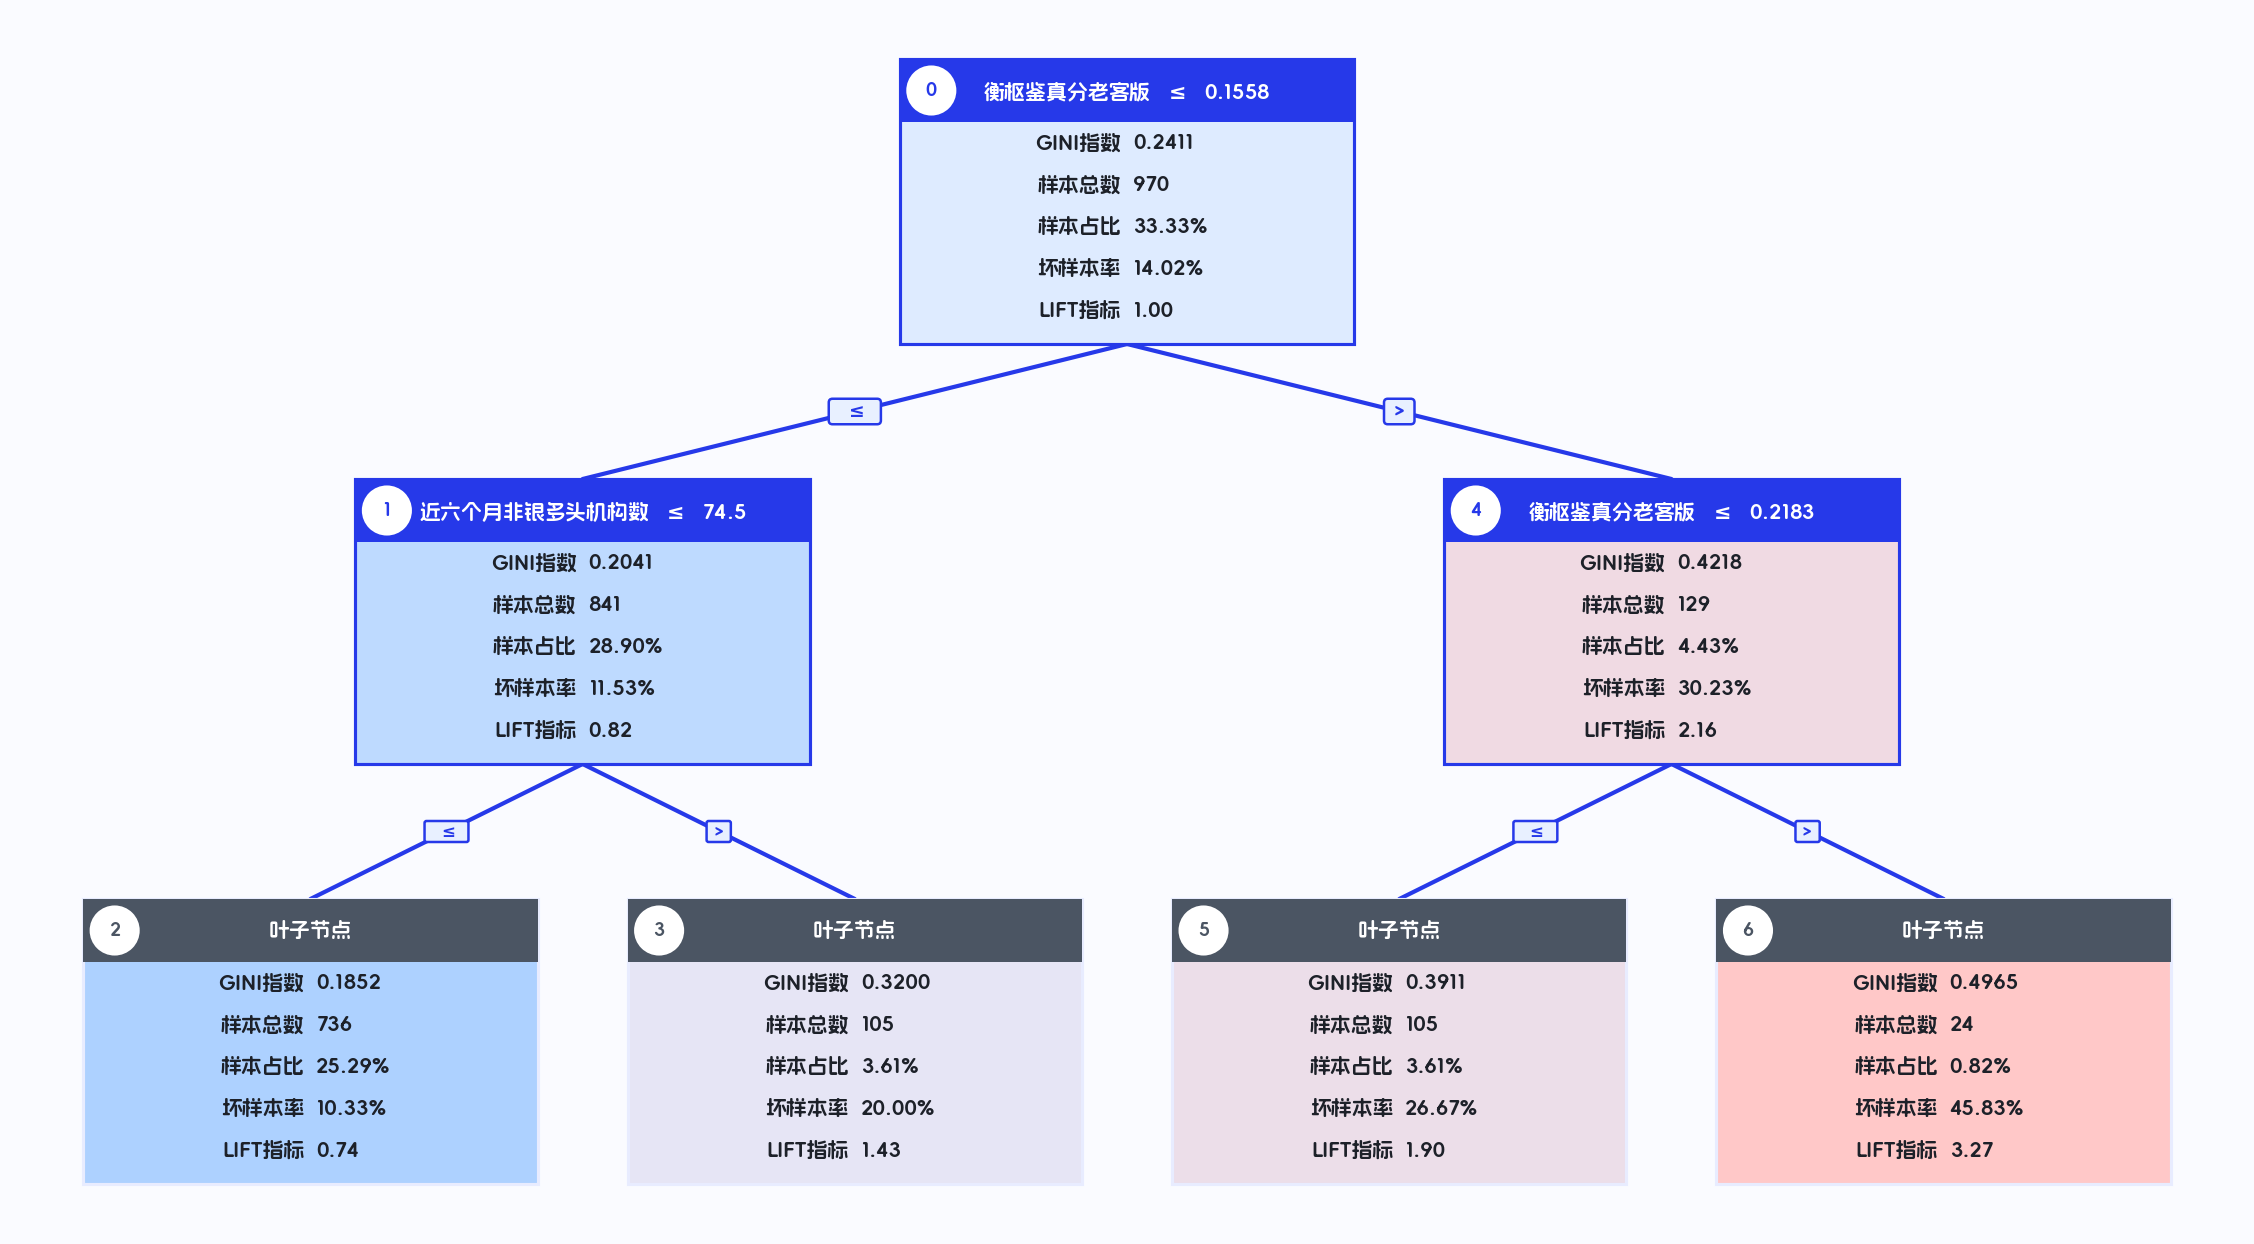

✅ matplotlib 渲染完成，图片已保存


In [36]:
# matplotlib 快速预览
# AntV G6 风格：卡片式节点 + 颜色语义 + 分支标签
fig = plot_tree_matplotlib(
    mte,
    figsize=(18, 12),
    dpi=150,
    save='tree_viz_output/cell04_matplotlib_basic.png',
)
plt.show()
print('✅ matplotlib 渲染完成，图片已保存')

---
## 5️⃣ pyecharts 交互式可视化

In [37]:
# pyecharts 交互式 HTML
# 支持鼠标悬停 tooltip / 缩放 / 平移 / 导出
chart = plot_tree_pyecharts(
    mte,
    title='决策树可视化 — AntV G6 风格',
    width='1400px',
    height='900px',
    save='tree_viz_output/cell05_pyecharts_basic.html',
)
chart.render_notebook()

---
## 6️⃣ graphviz 高质量矢量图

✅ graphviz 渲染完成


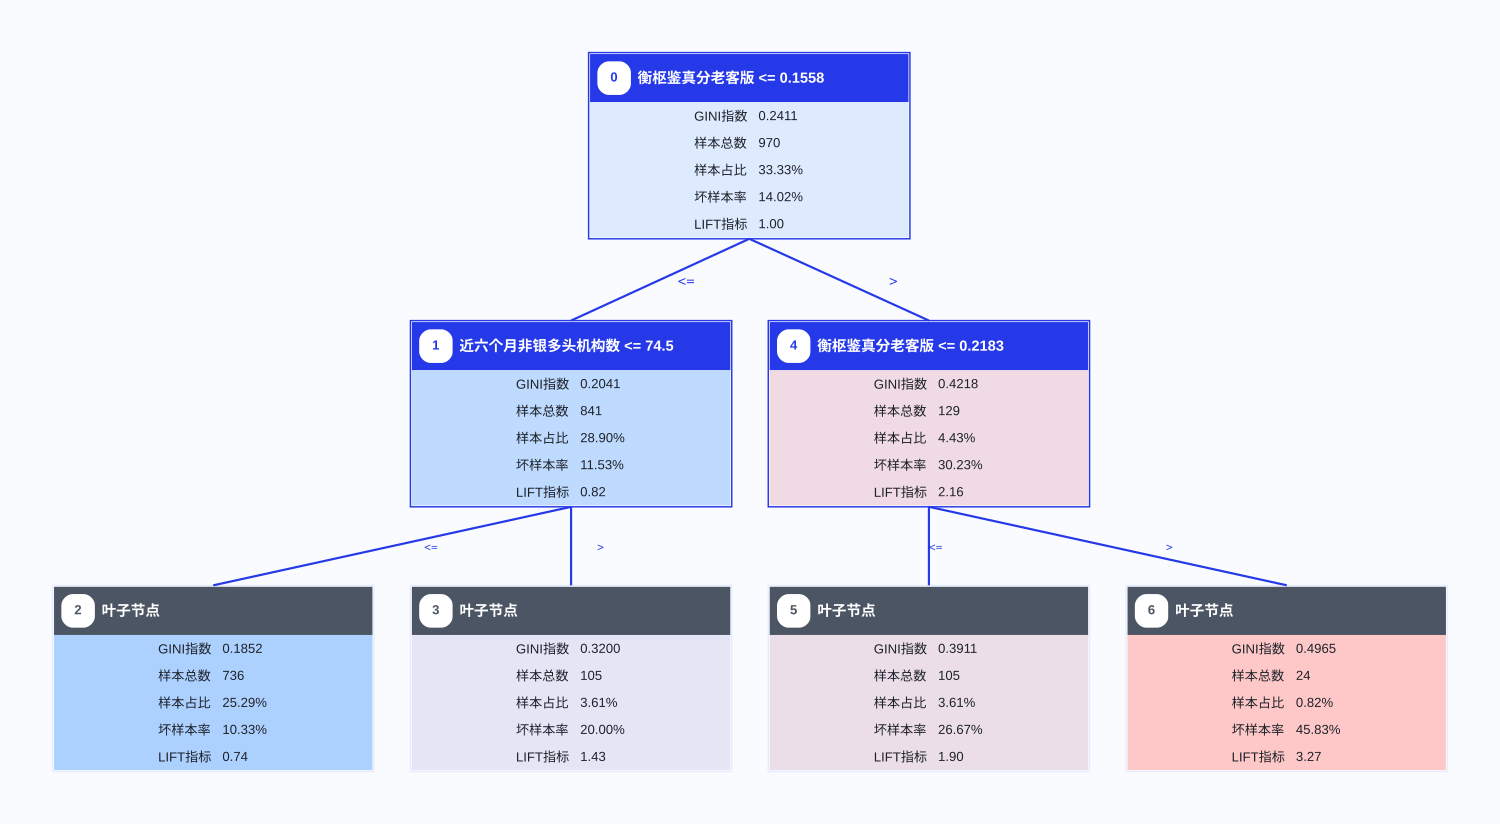

In [38]:
# graphviz 高质量矢量图（适合嵌入报告）
src = plot_tree_graphviz(
    mte,
    save='tree_viz_output/cell06_graphviz_basic.png',
    figsize=(10, 6),
)
print('✅ graphviz 渲染完成')
src

---
## 7️⃣ DecisionTreeViz 统一 API

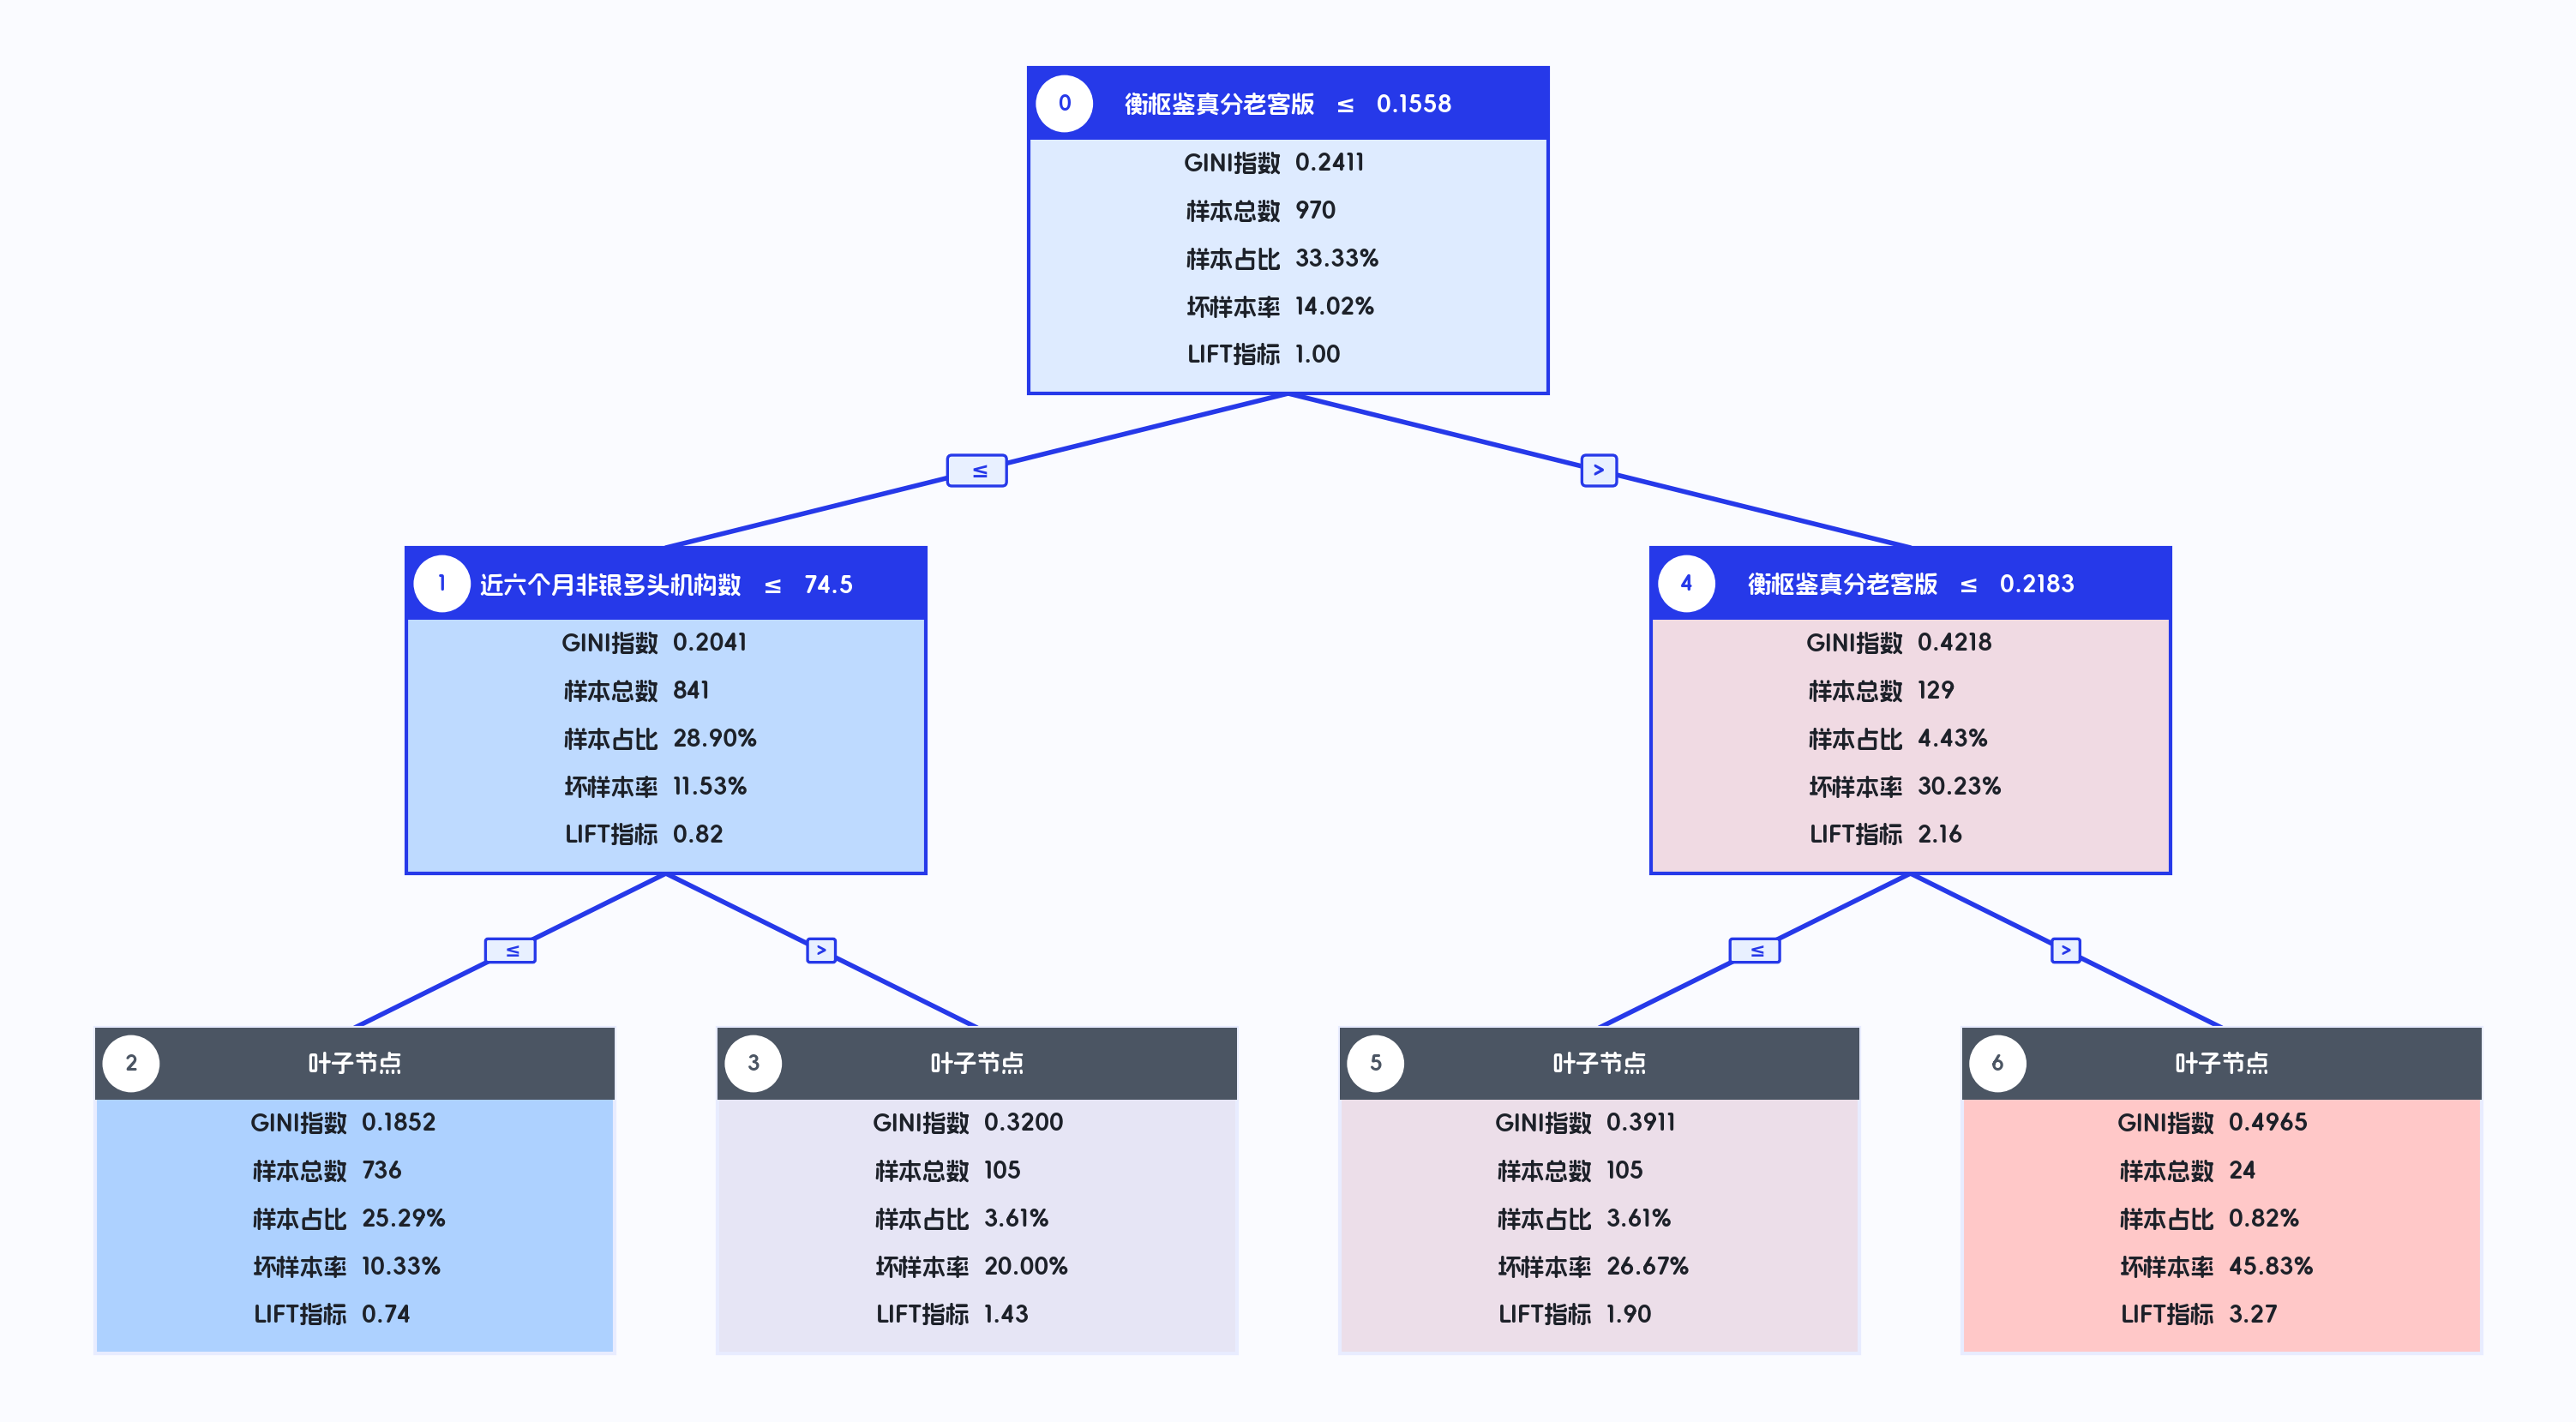

✅ DecisionTreeViz (matplotlib) 完成


In [39]:
# 统一 API：按需切换渲染后端
viz_mpl = DecisionTreeViz(backend='matplotlib', figsize=(18, 12), dpi=200)
fig = viz_mpl.plot(mte, save='tree_viz_output/cell07_unified_mpl.png')
plt.show()
print('✅ DecisionTreeViz (matplotlib) 完成')

In [40]:
viz_echarts = DecisionTreeViz(backend='pyecharts', title='决策树 — 统一 API')
chart = viz_echarts.plot(mte, save='tree_viz_output/cell07_unified_pyecharts.html')
chart.render_notebook()

In [41]:
viz_gv = DecisionTreeViz(backend='graphviz')
src = viz_gv.plot(mte, save='tree_viz_output/cell07_unified_gv.png')
print('✅ DecisionTreeViz (graphviz) 完成')

✅ DecisionTreeViz (graphviz) 完成


---
## 8️⃣ 人工分裂（manual_split）— 业务经验注入

**核心场景**：数据驱动模型学到的分裂点不符合业务经验，需要人工干预。

In [42]:
# 在根节点（node=0）进行人工分裂
# 业务经验：衡枢鉴真分 ≤ 600 为高风险客群
mte_manual = ManualTreeExtractor(
    target=TARGET,
    max_depth=3,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42,
)
mte_manual.fit(df, feature_list=feature_list)
mte_manual.manual_split(
    df=df,
    feature_name='衡枢鉴真分老客版',
    threshold=600,
    node=0,
)
print('✅ 人工分裂完成（根节点：衡枢鉴真分老客版 ≤ 600）')
mte_manual.get_rule_table()

✅ 人工分裂完成（根节点：衡枢鉴真分老客版 ≤ 600）


,节点编号,是否叶子,规则表达式,样本数,样本占比,好样本数,坏样本数,坏账率,LIFT值,坏账改善,风险拒绝比
0,1,是,衡枢鉴真分老客版 <= 600.0000,970,1.0000,834,136,0.1402,1.0000,1.0000,1.0000
1,2,是,衡枢鉴真分老客版 > 600.0000,0,0.0000,0,0,0.0000,0.0000,0.0000,0.0000


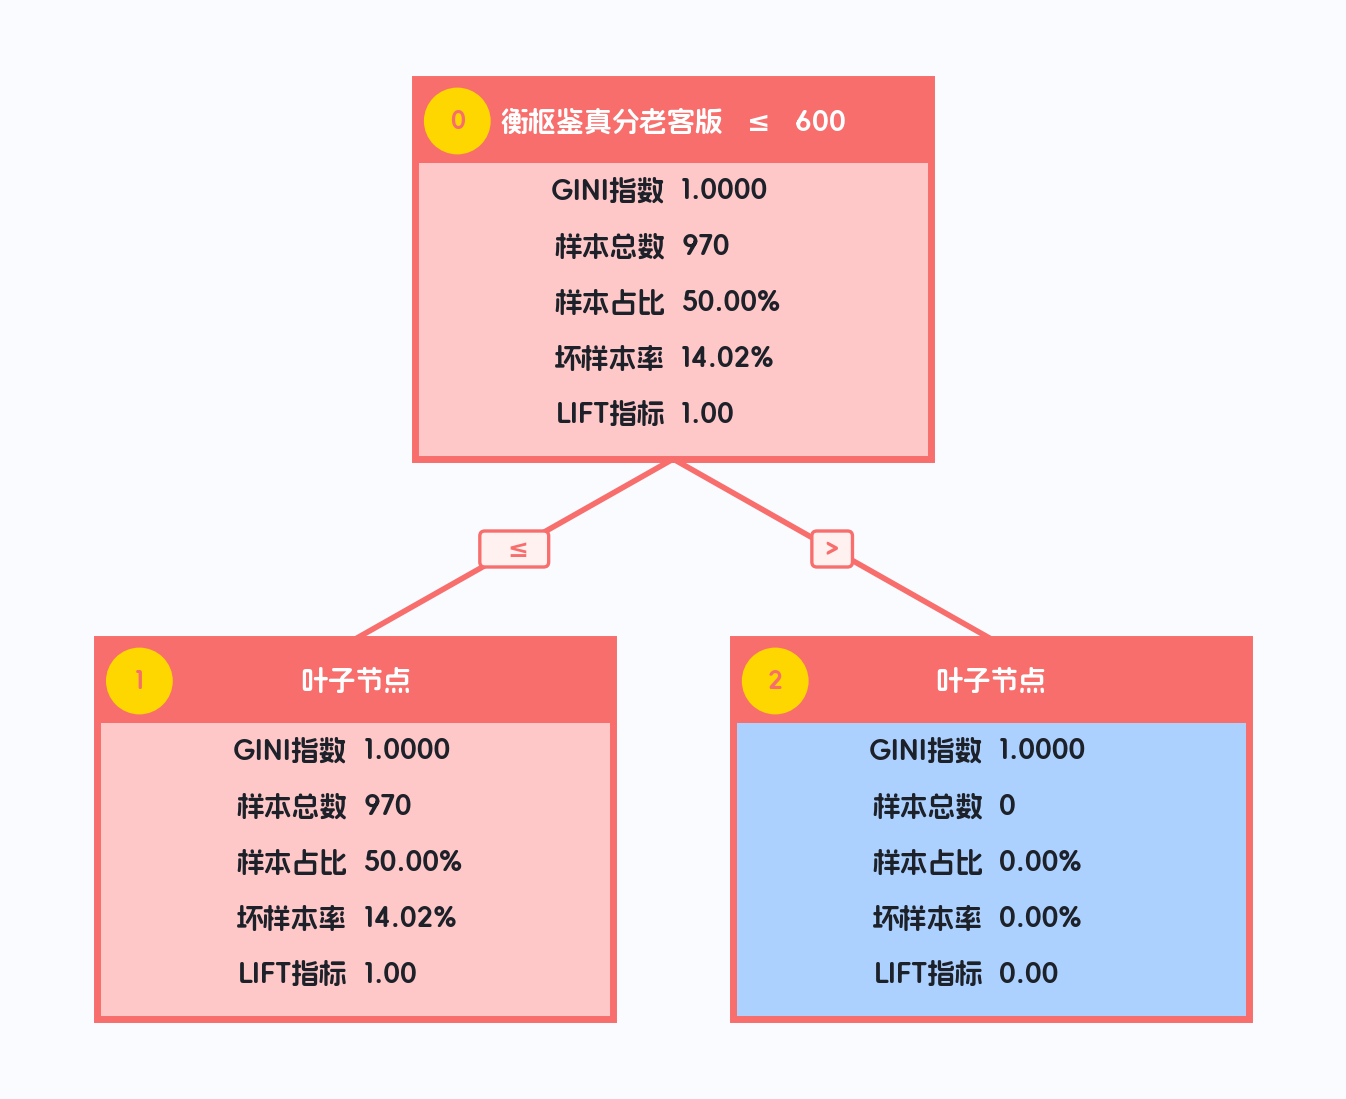

✅ matplotlib 可视化完成（紫色边框=人工分裂节点）


In [43]:
fig = plot_tree_matplotlib(
    mte_manual,
    figsize=(20, 14),
    dpi=200,
    save='tree_viz_output/cell08_manual_split_mpl.png',
)
plt.show()
print('✅ matplotlib 可视化完成（紫色边框=人工分裂节点）')

In [44]:
chart = plot_tree_pyecharts(
    mte_manual,
    title='人工分裂决策树 — 衡枢鉴真分老客版 ≤ 600',
    save='tree_viz_output/cell08_manual_split_pyecharts.html',
)
chart.render_notebook()

In [45]:
src = plot_tree_graphviz(
    mte_manual,
    save='tree_viz_output/cell08_manual_split_gv.png',
)
print('✅ graphviz 渲染完成')

✅ graphviz 渲染完成


---
## 9️⃣ 多轮人工分裂 — 完整风控规则注入

In [46]:
# 多轮人工分裂完整示例
mte_full = ManualTreeExtractor(
    target=TARGET,
    max_depth=3,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42,
)
mte_full.fit(df, feature_list=feature_list)

# 第一轮：根节点按衡枢鉴真分分裂（600分为界）
# mte_full.manual_split(df, feature_name='衡枢鉴真分老客版', threshold=600, node=3)
# 第二轮：左子节点按非银多头机构数分裂（>3 为高风险）
# mte_full.manual_split(df, feature_name='近六个月非银多头机构数', threshold=3, node=1)
# 第三轮：右子节点按青云24分裂
mte_full.manual_split(df, feature_name='青云24', threshold=50, node=2)

print('✅ 多轮人工分裂完成')
mte_full.get_rule_table()

✅ 多轮人工分裂完成


,节点编号,是否叶子,规则表达式,样本数,样本占比,好样本数,坏样本数,坏账率,LIFT值,坏账改善,风险拒绝比
0,1,否,衡枢鉴真分老客版 <= 0.1558,841,0.8670,744,97,0.1153,0.8226,-1.1563,-1.3337
1,2,否,衡枢鉴真分老客版 <= 0.1558 且 近六个月非银多头机构数 <= 74.5000,970,1.0000,834,136,0.1402,1.0000,1.0000,1.0000
2,3,否,衡枢鉴真分老客版 <= 0.1558 且 近六个月非银多头机构数 > 74.5000,105,0.1082,84,21,0.2000,1.4265,0.0518,0.4782
3,4,是,衡枢鉴真分老客版 <= 0.1558 且 近六个月非银多头机构数 > 74.5000 且 青云24 <= 595.5000,52,0.0536,37,15,0.2885,2.0574,0.0599,1.1173
4,5,是,衡枢鉴真分老客版 <= 0.1558 且 近六个月非银多头机构数 > 74.5000 且 青云24 > 595.5000,53,0.0546,47,6,0.1132,0.8074,-0.0111,-0.2037
5,6,否,衡枢鉴真分老客版 > 0.1558,129,0.1330,90,39,0.3023,2.1563,0.1774,1.3337
6,7,否,衡枢鉴真分老客版 <= 0.2183 且 衡枢鉴真分老客版 > 0.1558,105,0.1082,77,28,0.2667,1.9020,0.1095,1.0114
7,8,是,衡枢鉴真分老客版 <= 0.1681 且 衡枢鉴真分老客版 > 0.1558,32,0.0330,20,12,0.3750,2.6746,0.0571,1.7318
8,9,是,衡枢鉴真分老客版 <= 0.2183 且 衡枢鉴真分老客版 > 0.1681,73,0.0753,57,16,0.2192,1.5633,0.0458,0.6091
9,10,是,衡枢鉴真分老客版 > 0.2183,24,0.0247,13,11,0.4583,3.2690,0.0576,2.3266


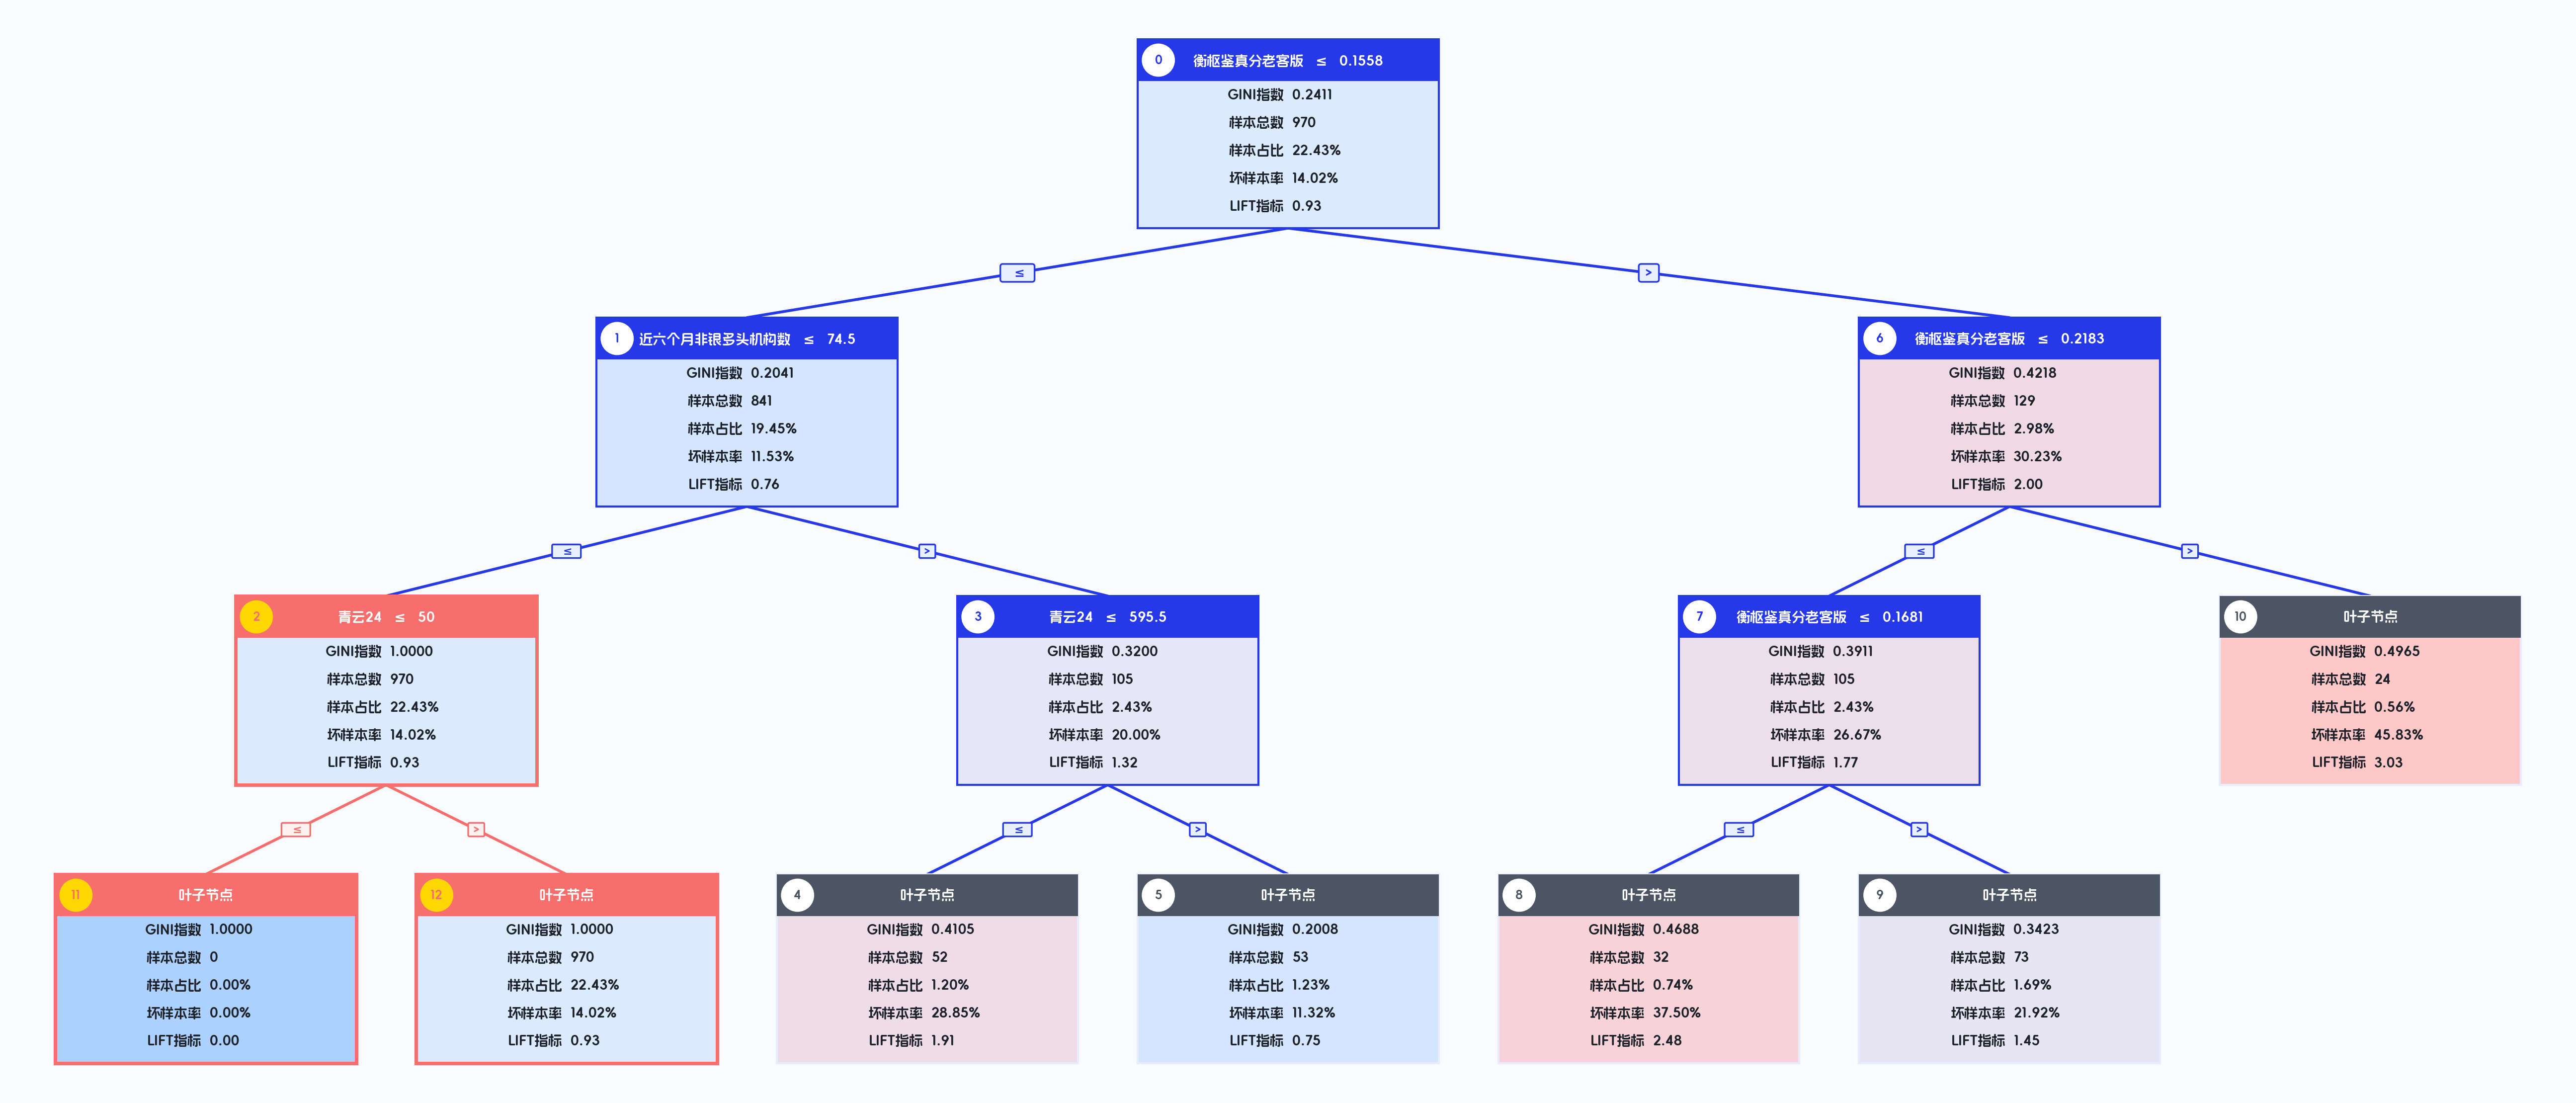

✅ matplotlib 完整树可视化完成


In [47]:
fig = plot_tree_matplotlib(
    mte_full,
    figsize=(22, 16),
    dpi=200,
    save='tree_viz_output/cell09_full_manual_mpl.png',
)
plt.show()
print('✅ matplotlib 完整树可视化完成')

In [65]:
chart = plot_tree_pyecharts(
    mte_full,
    # title='多轮人工分裂决策树 — 完整风控规则',
    save='tree_viz_output/cell09_full_manual_pyecharts.html',
)
chart.render_notebook()

✅ graphviz PDF 生成完成（适合报告嵌入）


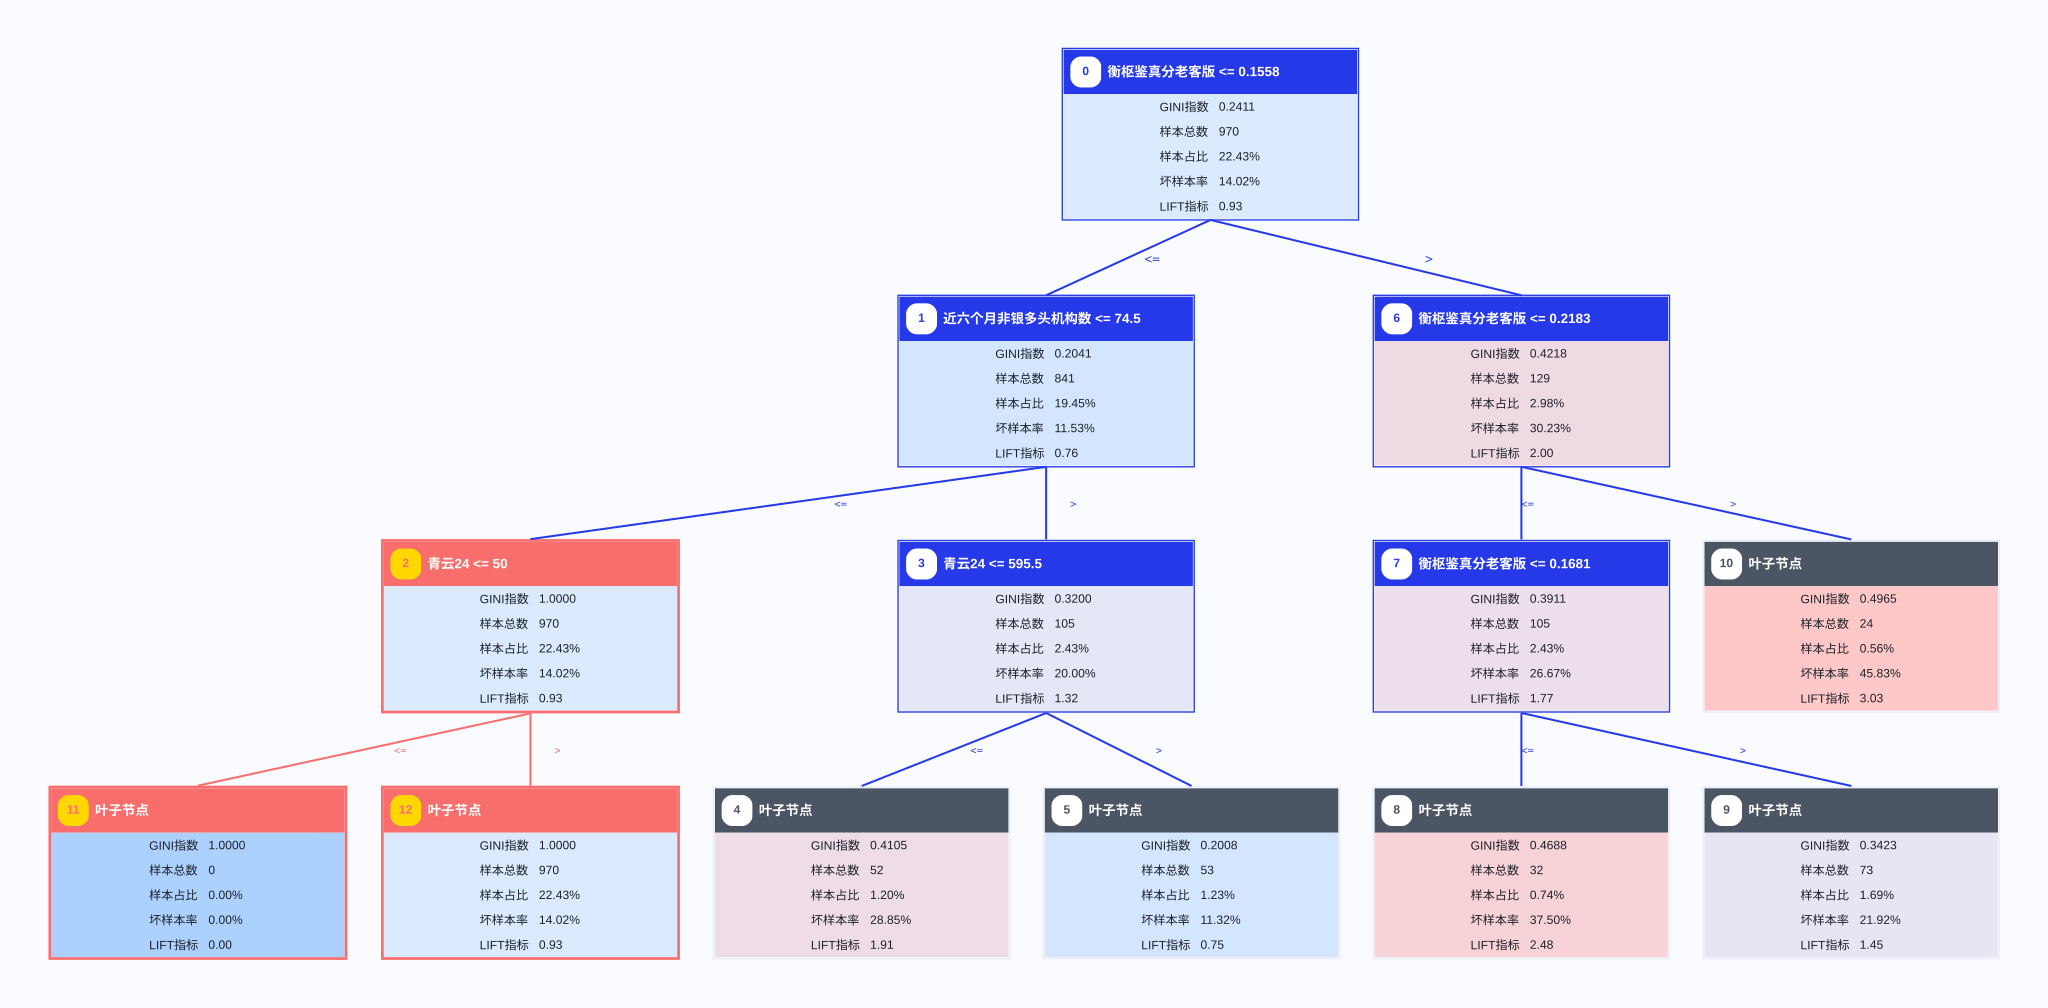

In [49]:
src = plot_tree_graphviz(
    mte_full,
    save='tree_viz_output/cell09_full_manual_gv.pdf',
)
print('✅ graphviz PDF 生成完成（适合报告嵌入）')
src

---
## 🔟 删除节点（delete_node）— 简化树结构

In [50]:
# 将指定节点及其子树裁剪为叶子节点
mte_pruned = ManualTreeExtractor(
    target=TARGET, max_depth=3,
    min_samples_split=50, min_samples_leaf=20, random_state=42,
)
mte_pruned.fit(df, feature_list=feature_list)
mte_pruned.manual_split(df, feature_name='衡枢鉴真分老客版', threshold=600, node=0)
mte_pruned.manual_split(df, feature_name='近六个月非银多头机构数', threshold=3, node=1)
mte_pruned.manual_split(df, feature_name='青云24', threshold=50, node=2)

print(f'删除前节点数：{len(mte_pruned._tree_info.feature)}')
mte_pruned.delete_node(node=3)
print(f'删除后节点数：{len(mte_pruned._tree_info.feature)}')
mte_pruned.get_rule_table()

删除前节点数：7
删除后节点数：7


,节点编号,是否叶子,规则表达式,样本数,样本占比,好样本数,坏样本数,坏账率,LIFT值,坏账改善,风险拒绝比
0,1,否,衡枢鉴真分老客版 <= 600.0000,970,1.0000,834,136,0.1402,1.0000,1.0000,1.0000
1,2,否,衡枢鉴真分老客版 > 600.0000,970,1.0000,834,136,0.1402,1.0000,1.0000,1.0000
2,3,是,衡枢鉴真分老客版 <= 600.0000 且 近六个月非银多头机构数 <= 3.0000,0,0.0000,0,0,0.0000,0.0000,0.0000,0.0000
3,4,是,衡枢鉴真分老客版 <= 600.0000 且 近六个月非银多头机构数 > 3.0000,970,1.0000,834,136,0.1402,1.0000,1.0000,1.0000
4,5,是,衡枢鉴真分老客版 > 600.0000 且 青云24 <= 50.0000,0,0.0000,0,0,0.0000,0.0000,0.0000,0.0000
5,6,是,衡枢鉴真分老客版 > 600.0000 且 青云24 > 50.0000,970,1.0000,834,136,0.1402,1.0000,1.0000,1.0000


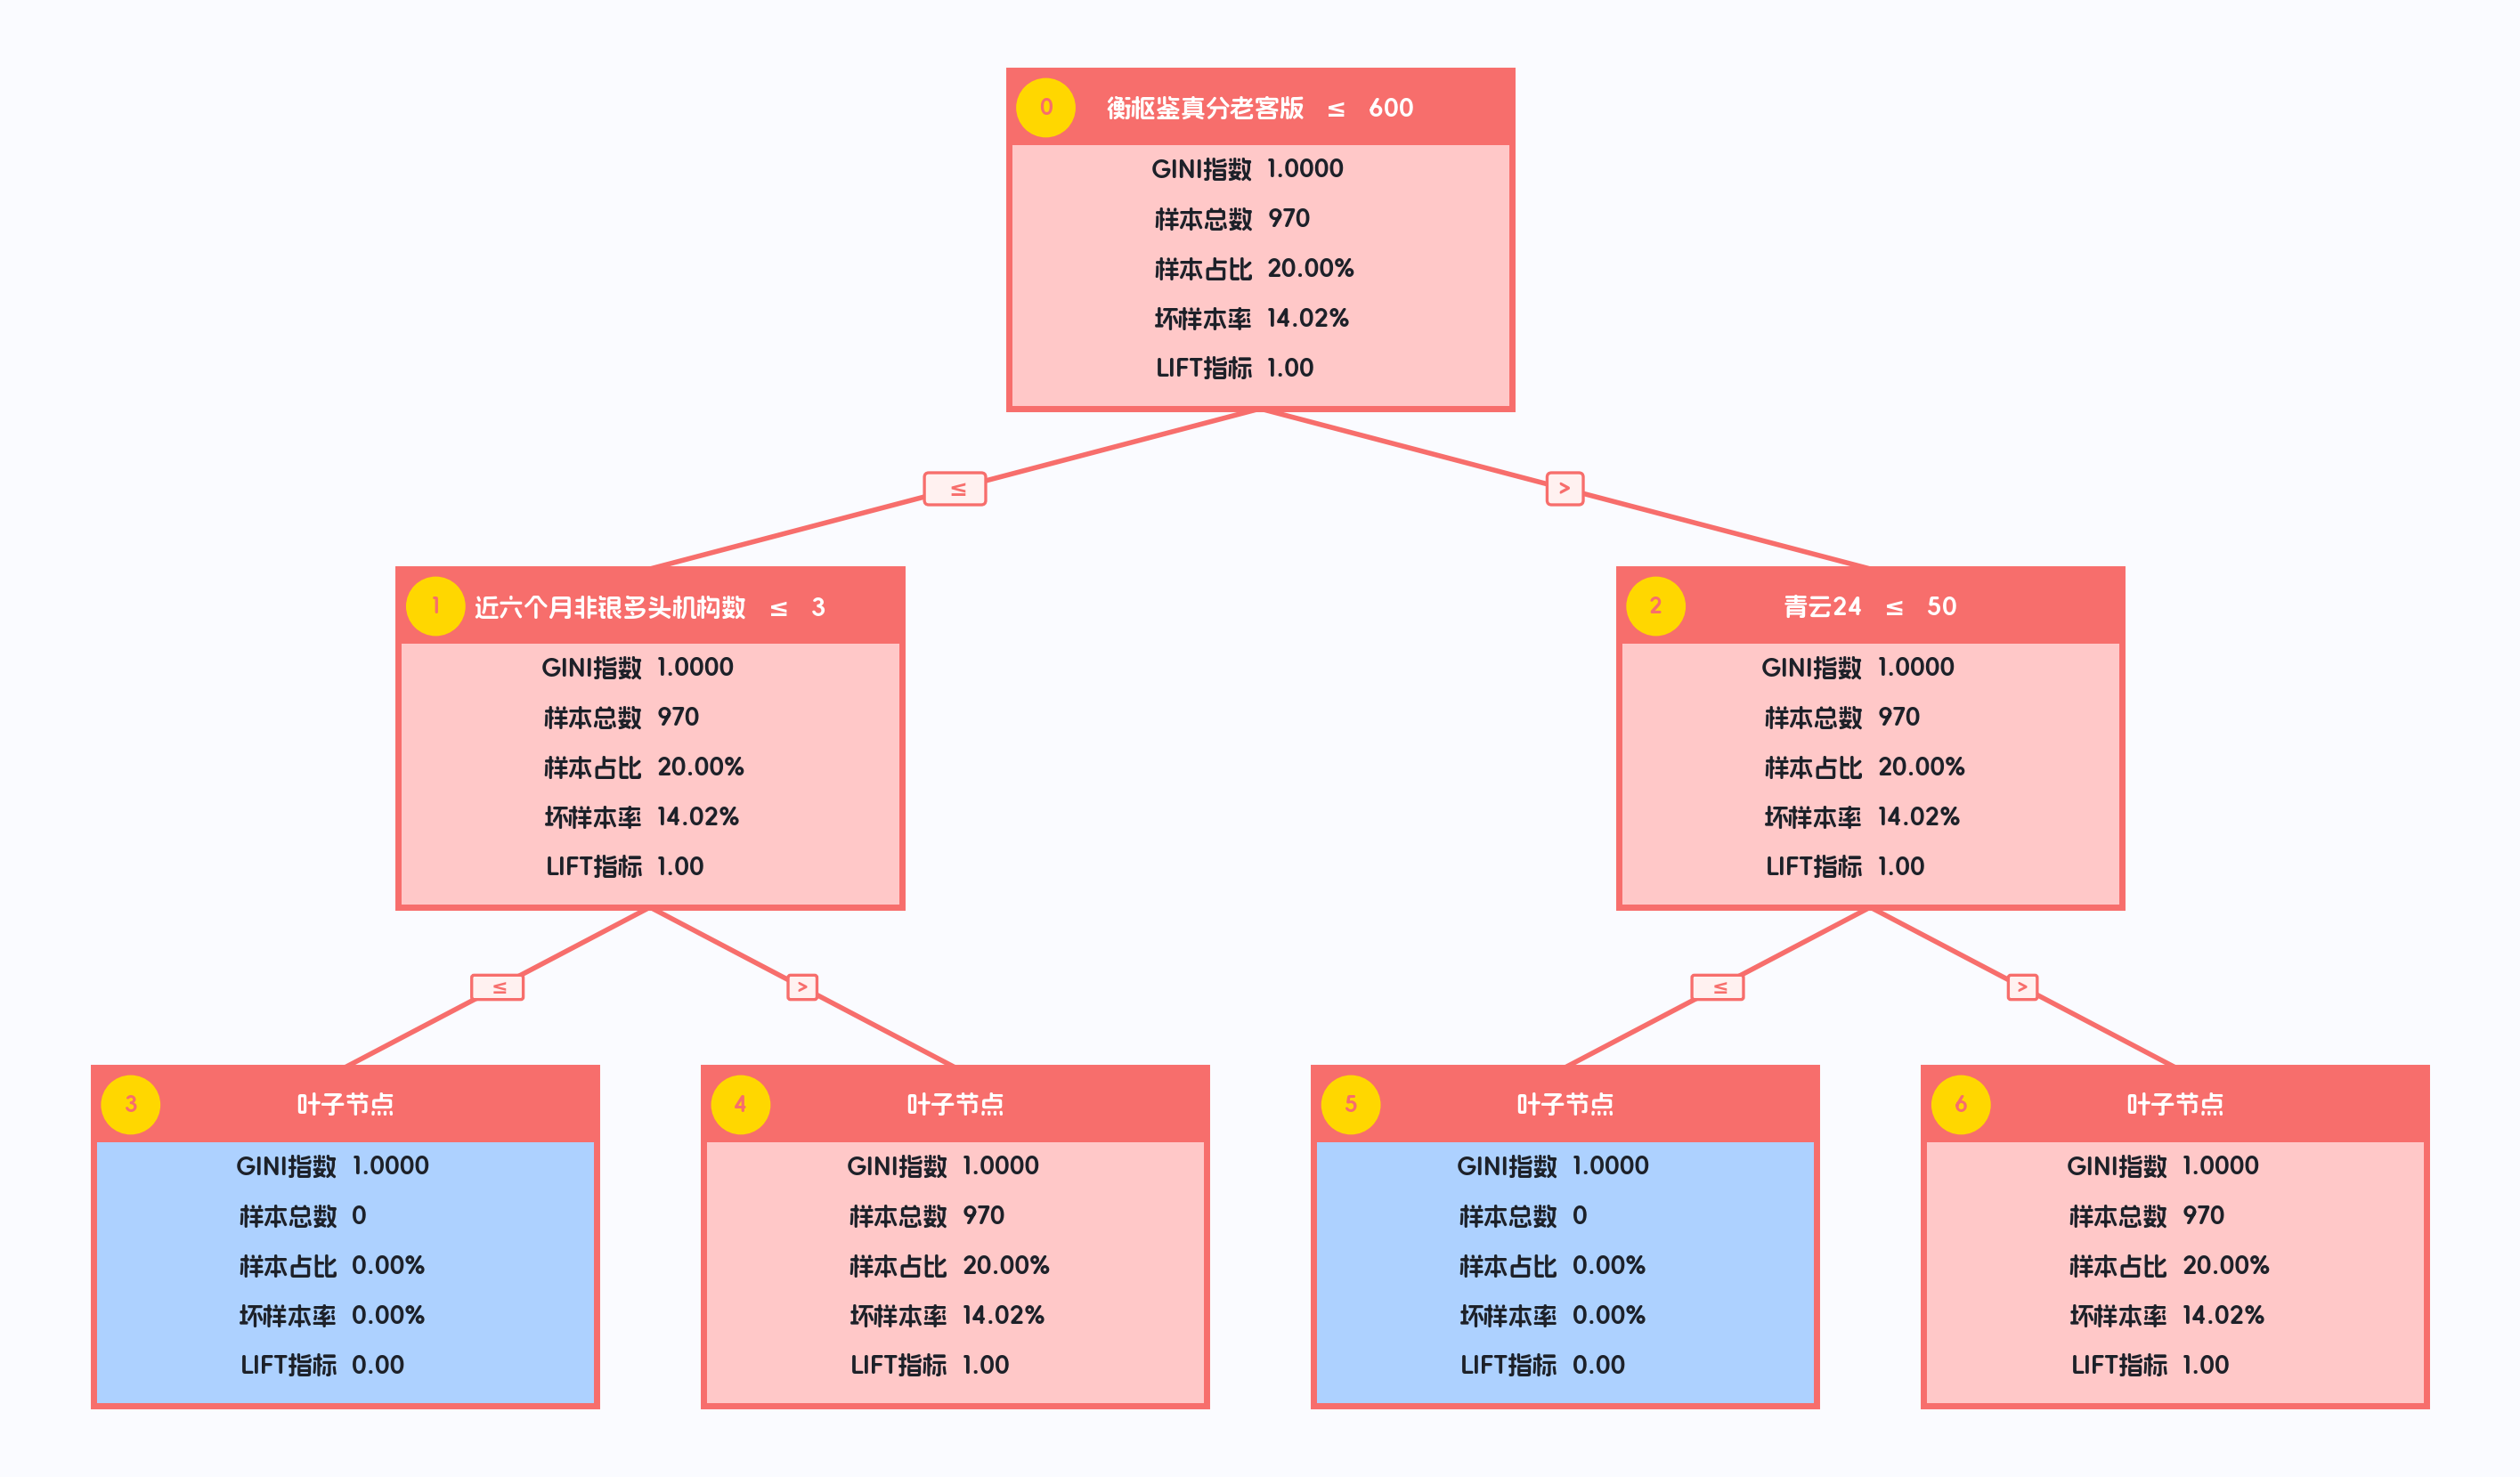

✅ 裁剪后树可视化完成


In [51]:
fig = plot_tree_matplotlib(
    mte_pruned,
    figsize=(20, 14),
    dpi=200,
    save='tree_viz_output/cell10_pruned_mpl.png',
)
plt.show()
print('✅ 裁剪后树可视化完成')

---
## 1️⃣1️⃣ DecisionTreeAnalyzer 可视化

In [52]:
# DecisionTreeAnalyzer 是标准 sklearn 决策树包装器
fitter = DecisionTreeAnalyzer(
    target=TARGET,
    feature_list=feature_list,
    tree_params={'max_depth': 3, 'min_samples_split': 50, 'random_state': 42},
)
fitter.fit(df)
print(f'✅ DecisionTreeAnalyzer 训练完成：{repr(fitter)}')
fitter.get_rule_table()

✅ DecisionTreeAnalyzer 训练完成：DecisionTreeAnalyzer(target='FPD', features=['衡枢鉴真分老客版', '近六个月非银多头机构数', '青云24'], leaves=6)


,节点编号,是否叶子,规则表达式,样本数,样本占比,好样本数,坏样本数,坏账率,LIFT值
0,1,否,衡枢鉴真分老客版 <= 0.1558,841,0.8670,744,97,0.1153,0.8226
1,2,否,衡枢鉴真分老客版 <= 0.1558 且 近六个月非银多头机构数 <= 87.5000,835,0.8608,741,94,0.1126,0.8029
2,3,是,衡枢鉴真分老客版 <= 0.1558 且 近六个月非银多头机构数 <= 74.5000,736,0.7588,660,76,0.1033,0.7365
3,4,是,衡枢鉴真分老客版 <= 0.1558 且 近六个月非银多头机构数 <= 87.5000 且 近六个月非银多头机构数 > 74.5000,99,0.1021,81,18,0.1818,1.2968
4,5,是,衡枢鉴真分老客版 <= 0.1558 且 近六个月非银多头机构数 > 87.5000,6,0.0062,3,3,0.5000,3.5662
5,6,否,衡枢鉴真分老客版 > 0.1558,129,0.1330,90,39,0.3023,2.1563
6,7,是,衡枢鉴真分老客版 > 0.1558 且 青云24 <= 490.5000,8,0.0082,8,0,0.0000,0.0000
7,8,否,衡枢鉴真分老客版 > 0.1558 且 青云24 > 490.5000,121,0.1247,82,39,0.3223,2.2989
8,9,是,衡枢鉴真分老客版 <= 0.2081 且 衡枢鉴真分老客版 > 0.1558 且 青云24 > 490.5000,95,0.0979,69,26,0.2737,1.9520
9,10,是,衡枢鉴真分老客版 > 0.2081 且 青云24 > 490.5000,26,0.0268,13,13,0.5000,3.5662


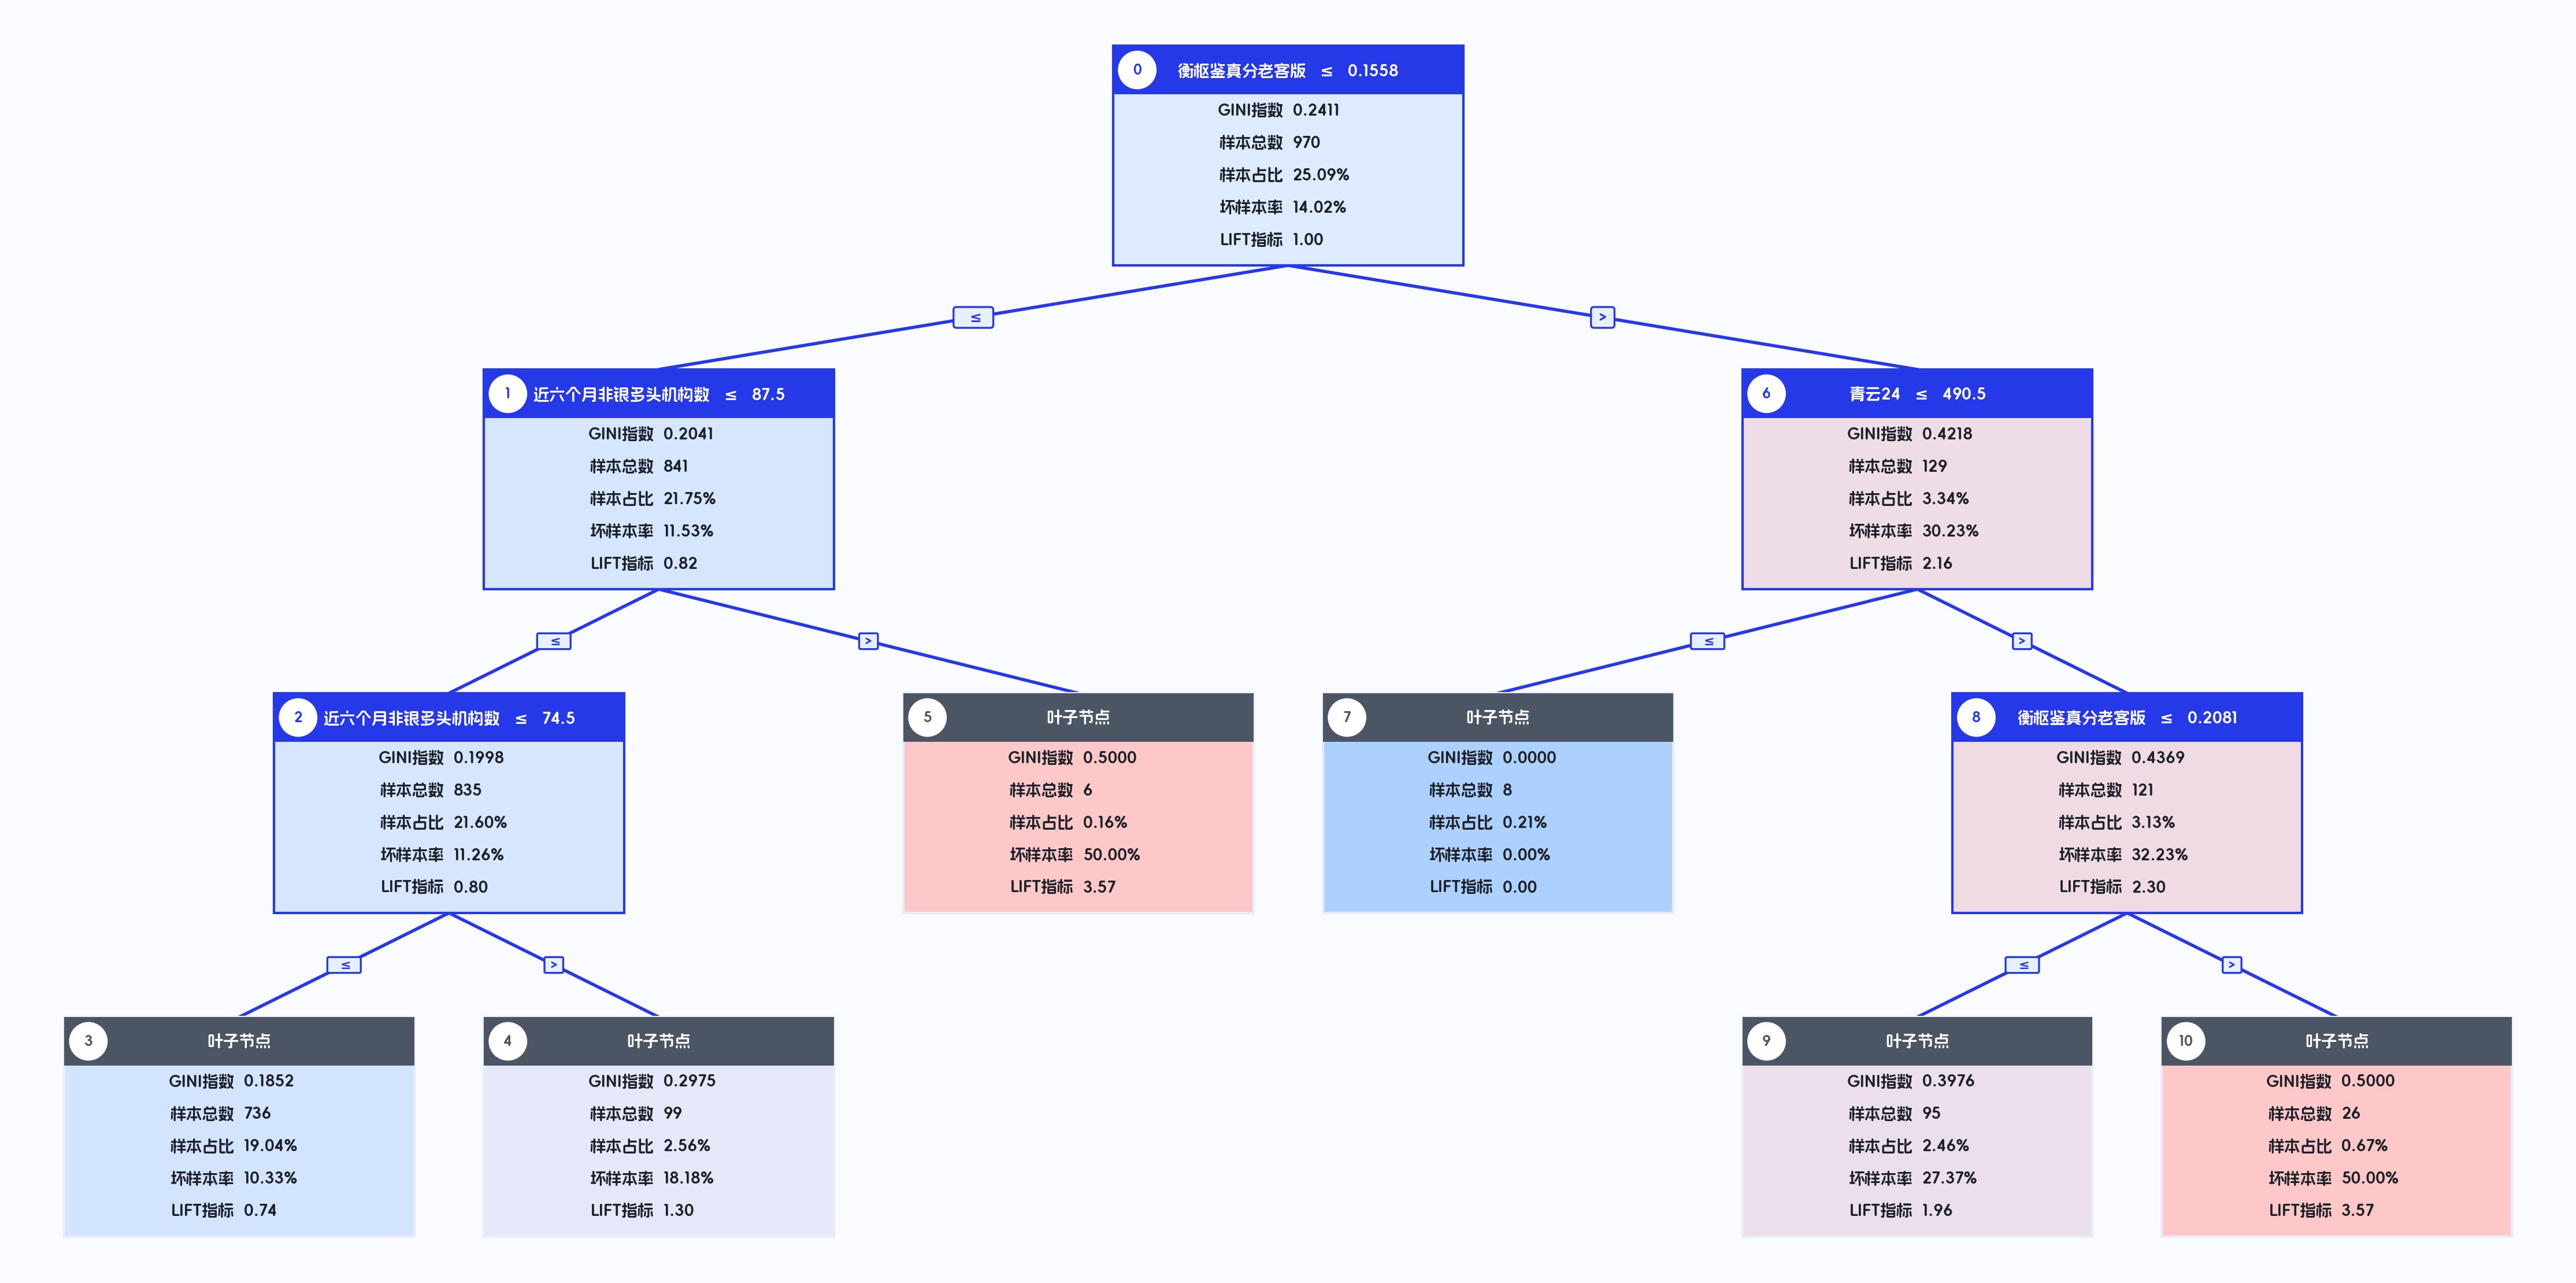

✅ DecisionTreeAnalyzer matplotlib 可视化完成


In [53]:
fig = plot_tree_matplotlib(
    fitter,
    figsize=(20, 14),
    dpi=200,
    save='tree_viz_output/cell11_autofitter_mpl.png',
)
plt.show()
print('✅ DecisionTreeAnalyzer matplotlib 可视化完成')

In [54]:
chart = plot_tree_pyecharts(
    fitter,
    title='DecisionTreeAnalyzer — 标准决策树',
    save='tree_viz_output/cell11_autofitter_pyecharts.html',
)
chart.render_notebook()

In [55]:
src = plot_tree_graphviz(
    fitter,
    save='tree_viz_output/cell11_autofitter_gv.pdf',
)
print('✅ DecisionTreeAnalyzer graphviz 渲染完成')

✅ DecisionTreeAnalyzer graphviz 渲染完成


---
## 1️⃣2️⃣ sklearn DecisionTreeClassifier 可视化

直接传入 sklearn 决策树对象，无需任何包装。

In [56]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42,
)
X = df[feature_list]
y = df[TARGET]
clf.fit(X, y)
print(f'✅ sklearn 决策树训练完成：节点数={clf.tree_.node_count}, 叶子数={clf.get_n_leaves()}')

✅ sklearn 决策树训练完成：节点数=13, 叶子数=7


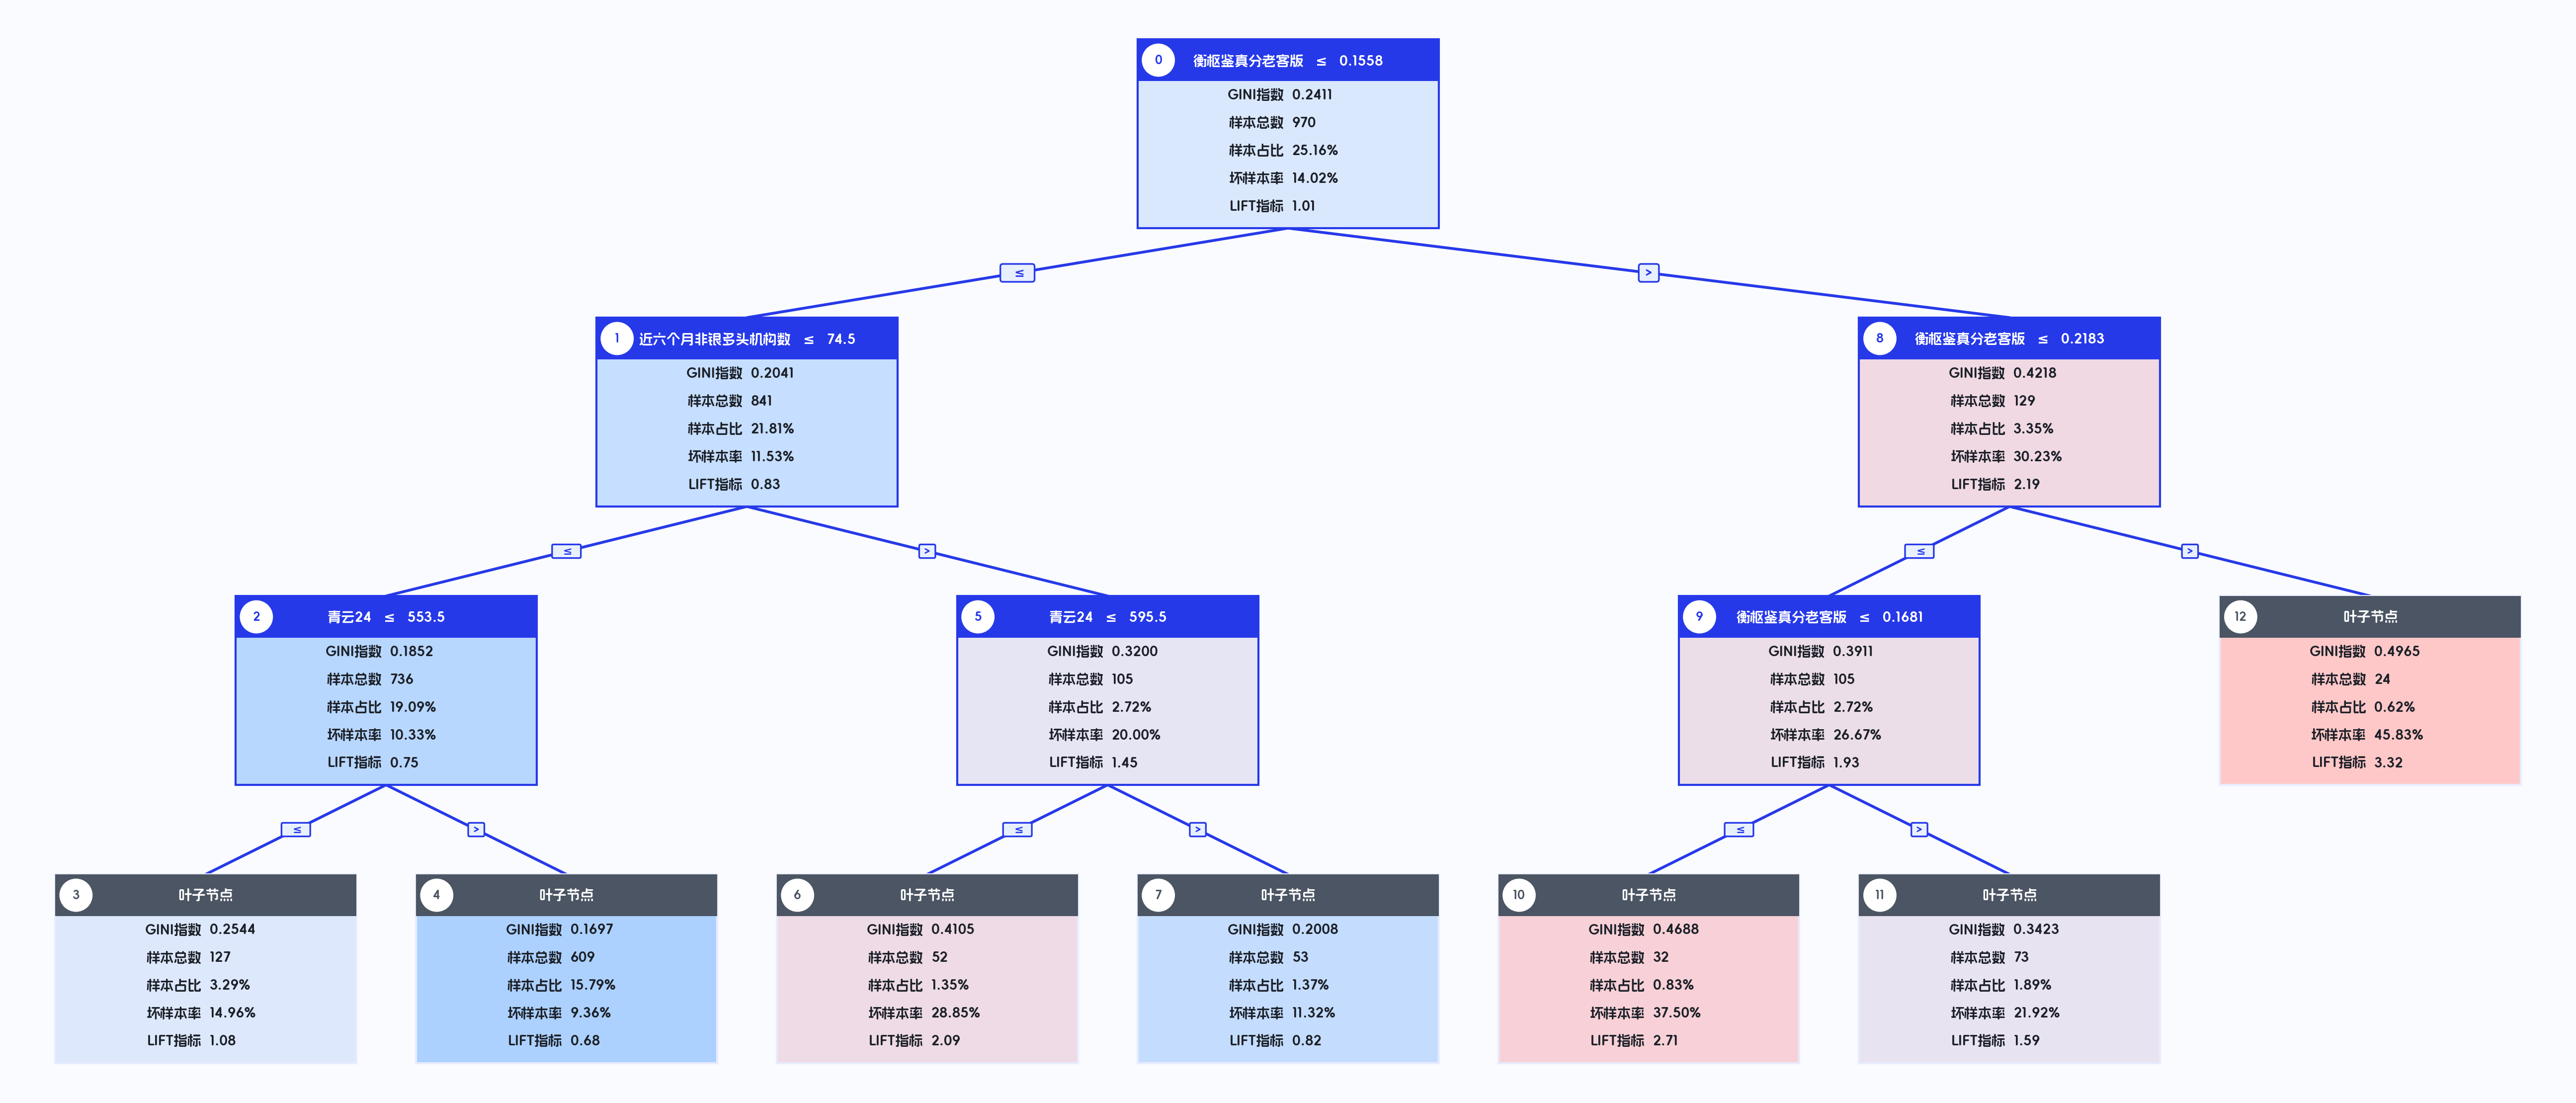

✅ sklearn DecisionTreeClassifier matplotlib 可视化完成


In [57]:
fig = plot_tree_matplotlib(
    clf,
    feature_names=feature_list,
    figsize=(20, 14),
    dpi=200,
    save='tree_viz_output/cell12_sklearn_mpl.png',
)
plt.show()
print('✅ sklearn DecisionTreeClassifier matplotlib 可视化完成')

In [58]:
chart = plot_tree_pyecharts(
    clf,
    feature_names=feature_list,
    title='sklearn DecisionTreeClassifier',
    save='tree_viz_output/cell12_sklearn_pyecharts.html',
)
chart.render_notebook()

In [59]:
src = plot_tree_graphviz(
    clf,
    feature_names=feature_list,
    save='tree_viz_output/cell12_sklearn_gv.pdf',
)
print('✅ sklearn DecisionTreeClassifier graphviz 渲染完成')

✅ sklearn DecisionTreeClassifier graphviz 渲染完成


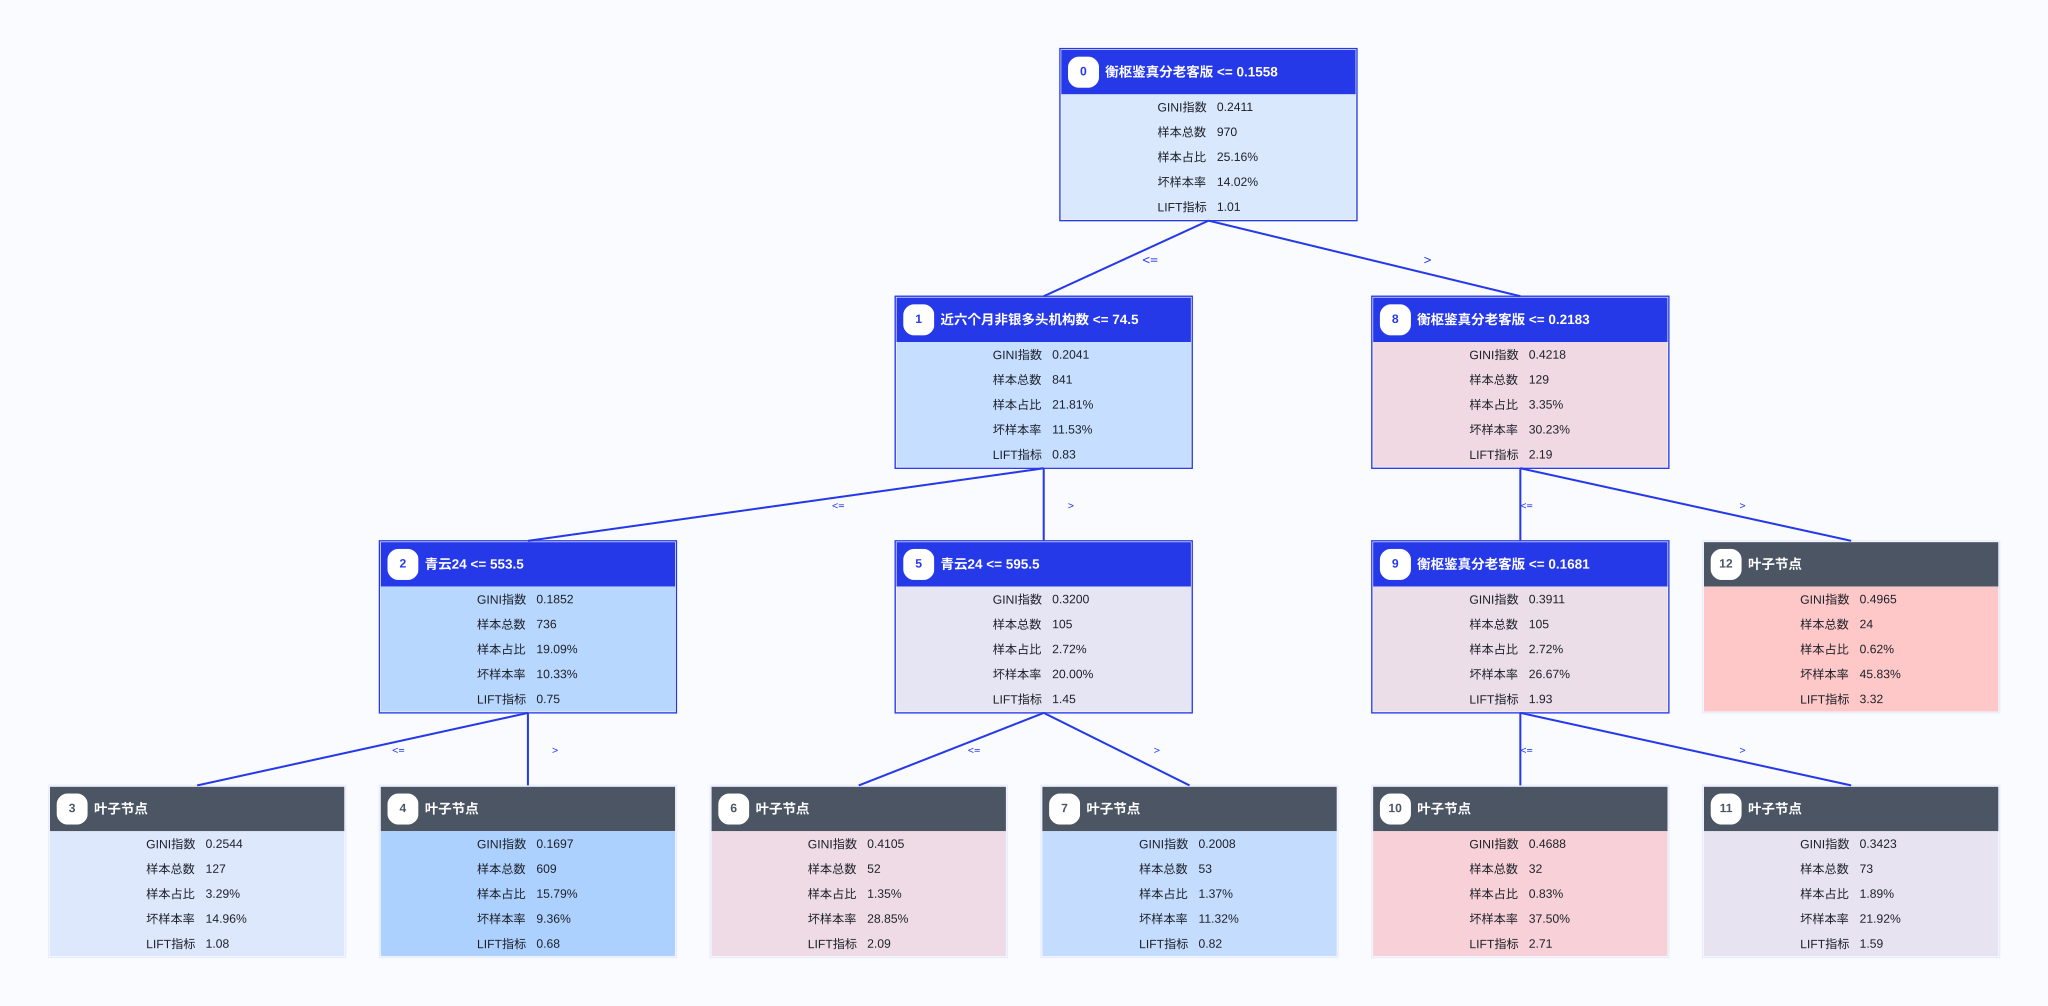

In [60]:
plot_tree_graphviz(
    clf,
    # feature_names=feature_list,
)

---
## 1️⃣3️⃣ 从 sklearn 导入后人工分裂

In [61]:
# 通过 from_sklearn() 从已训练的 sklearn 树创建 ManualTreeExtractor
mte_from_sklearn = ManualTreeExtractor.from_sklearn(
    clf,
    feature_names=feature_list,
    target=TARGET,
)
mte_from_sklearn.manual_split(df, feature_name='衡枢鉴真分老客版', threshold=600, node=0)
print('✅ 从 sklearn 导入并人工分裂完成')
mte_from_sklearn.get_rule_table()

✅ 从 sklearn 导入并人工分裂完成


,节点编号,是否叶子,规则表达式,样本数,样本占比,好样本数,坏样本数,坏账率,LIFT值,坏账改善,风险拒绝比
0,1,是,衡枢鉴真分老客版 <= 600.0000,970,1.0000,834,136,0.1402,0.0000,0.0000,0.0000
1,2,是,衡枢鉴真分老客版 > 600.0000,0,0.0000,0,0,0.0000,0.0000,0.0000,0.0000


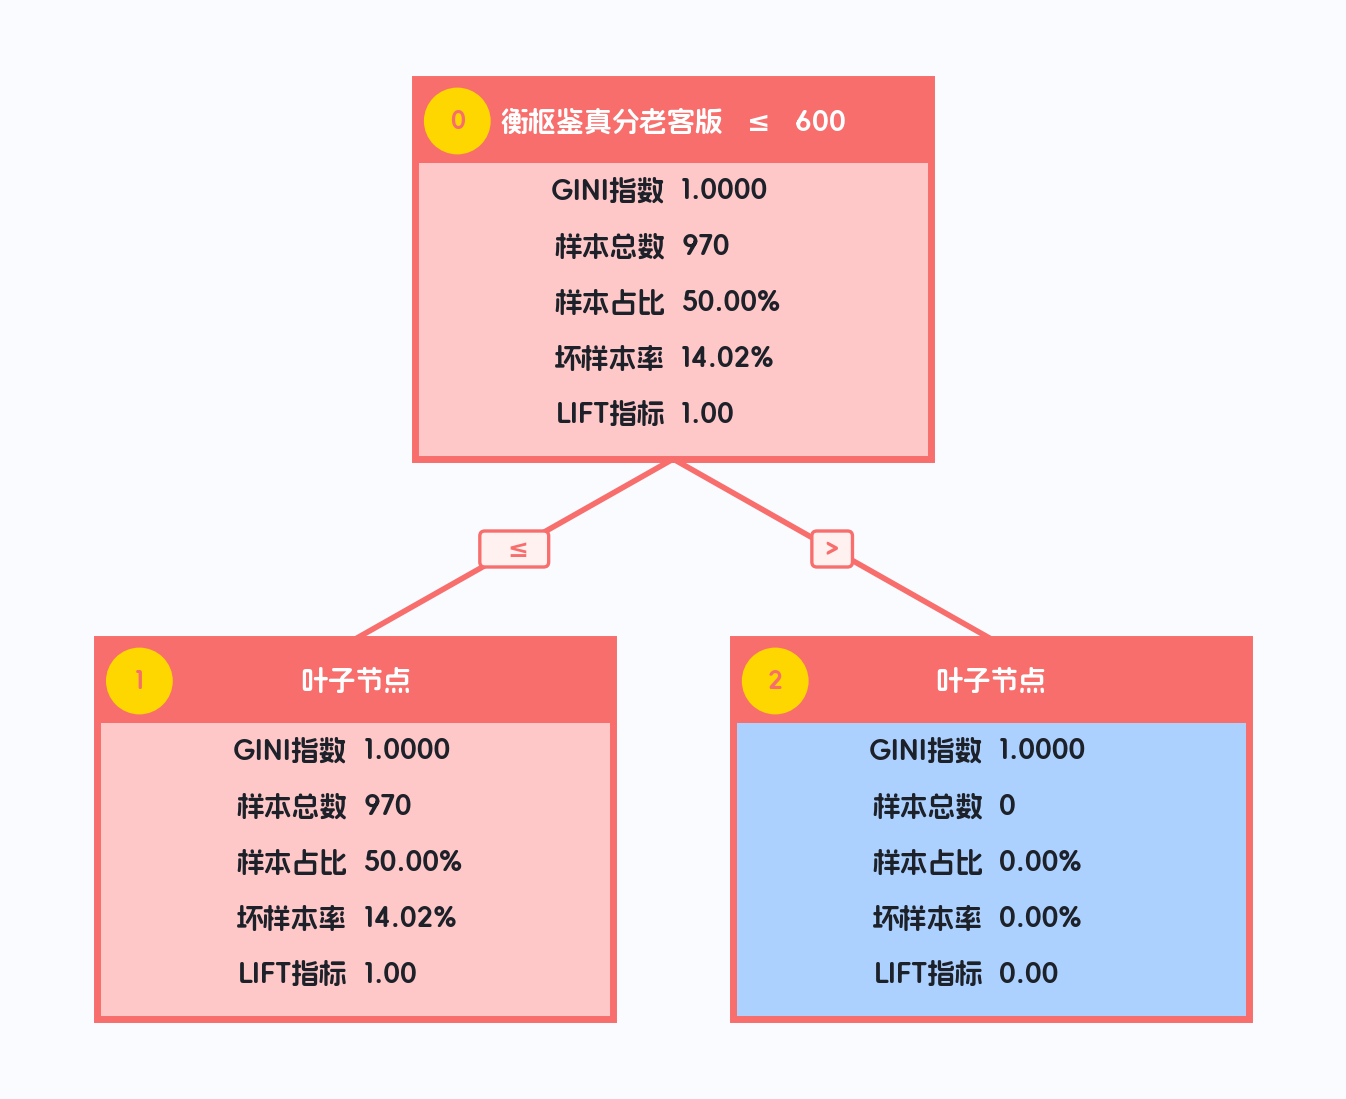

In [62]:
fig = plot_tree_matplotlib(
    mte_from_sklearn,
    figsize=(20, 14),
    dpi=200,
    save='tree_viz_output/cell13_from_sklearn_mpl.png',
)
plt.show()

In [63]:
chart = plot_tree_pyecharts(
    mte_from_sklearn,
    title='从 sklearn 导入后人工分裂',
    save='tree_viz_output/cell13_from_sklearn_pyecharts.html',
)
chart.render_notebook()

---
## 1️⃣4️⃣ 在新数据集上评估人工决策树

In [64]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.3, random_state=42)

# 在测试集上评估人工决策树
eval_result = mte_full.evaluate_on_new_data(df_test)
print('📊 测试集评估结果：')
eval_result

AttributeError: 'ManualTreeExtractor' object has no attribute 'evaluate_on_new_data'

In [ ]:
# 仅评估叶子节点（核心风控规则）
leaf_result = mte_full.evaluate_on_new_data(df_test, leaf_only=True)
print('📊 叶子节点评估结果（核心风控规则）：')
leaf_result

---
## 1️⃣5️⃣ 节点卡片内容详解

**AntV G6 风格节点卡片包含以下信息**：

| 指标 | 说明 |
|------|------|
| **NODE #N** | 节点编号 |
| **分裂条件** | 特征名 ≤ 阈值 |
| **GINI** | Gini 不纯度 |
| **样本总数** | 命中该节点的样本数 |
| **样本占比** | 占总样本的比例 |
| **坏样本率** | 坏账率（颜色即反映此值） |
| **LIFT指标** | 节点坏账率 / 整体坏账率（>1=高风险，<1=低风险） |

**连线标签**（仅根节点显示）：
- **≤ 分支**（蓝色）：满足分裂条件走左子树
- **> 分支**（红色）：不满足分裂条件走右子树

In [ ]:
# 展示节点指标的详细解读
print('=== 节点卡片指标解读 ===\n')
table = mte_full.get_rule_table()
for _, row in table.iterrows():
    node_id = row['节点编号']
    is_leaf = row['是否叶子']
    rule = row['规则表达式']
    n = row['样本数']
    pct = row['样本占比']
    br = row['坏账率']
    lift = row['LIFT值']
    risk = '🟢 低风险' if br < 0.1 else ('🟡 中风险' if br < 0.3 else '🔴 高风险')
    tag = '叶子' if is_leaf == '是' else '分裂'
    print(f'NODE #{node_id} [{tag}]：{rule or "（根节点）"}')
    print(f'  样本数：{n:,} ({pct:.1%}）  坏账率：{br:.2%}  LIFT：{lift:.2f}x  {risk}')
    print()

---
## 📋 总结

| 功能 | API |
|------|------|
| **matplotlib 快速预览** | `plot_tree_matplotlib(mte, save='tree.png')` |
| **pyecharts 交互图** | `plot_tree_pyecharts(mte, save='tree.html')` |
| **graphviz 矢量图** | `plot_tree_graphviz(mte, save='tree.pdf')`（渲染格式由 save 文件后缀自动推断） |
| **统一 API** | `DecisionTreeViz(backend='...').plot(mte)` |
| **人工分裂** | `mte.manual_split(df, feature, threshold, node)` |
| **删除节点** | `mte.delete_node(node)` |
| **规则表** | `mte.get_rule_table()` |
| **新数据评估** | `mte.evaluate_on_new_data(df_test)` |
| **从 sklearn 导入** | `ManualTreeExtractor.from_sklearn(clf)` |